Importing Dataset

In [ ]:
from google.colab import files
files.upload()  # Upload kaggle.json when prompted

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"donumar","key":"b452265314af59234994a8b625b00df3"}'}

In [ ]:
import os
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
 90% 313M/346M [00:00<00:00, 596MB/s]
100% 346M/346M [00:00<00:00, 633MB/s]


In [ ]:
import zipfile

with zipfile.ZipFile("intel-image-classification.zip", "r") as zip_ref:
    zip_ref.extractall("intel")


In [ ]:
import os

# List the main extracted folder
print("Main folder contents:")
print(os.listdir("intel"))

# List training subfolder
print("\nTraining folder contents:")
print(os.listdir("intel/seg_train"))

# List test subfolder
print("\nTest folder contents:")
print(os.listdir("intel/seg_test"))

Main folder contents:
['seg_train', 'seg_pred', 'seg_test']

Training folder contents:
['seg_train']

Test folder contents:
['seg_test']


Pre-Processing

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
train_dir = "intel/seg_train/seg_train"
test_dir = "intel/seg_test/seg_test"

# Data augmentation for training, just rescale for testing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # Use 20% of training as validation
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


data exploration

In [ ]:
# Number of training, validation, and testing examples
n_train = train_generator.samples
n_val = val_generator.samples
n_test = test_generator.samples

# Image size from generator (target_size)
image_size = train_generator.target_size

print("Number of training examples:", n_train)
print("Number of validation examples:", n_val)
print("Number of testing examples:", n_test)
print("Each image is of size:", image_size)

Number of training examples: 11230
Number of validation examples: 2804
Number of testing examples: 3000
Each image is of size: (150, 150)


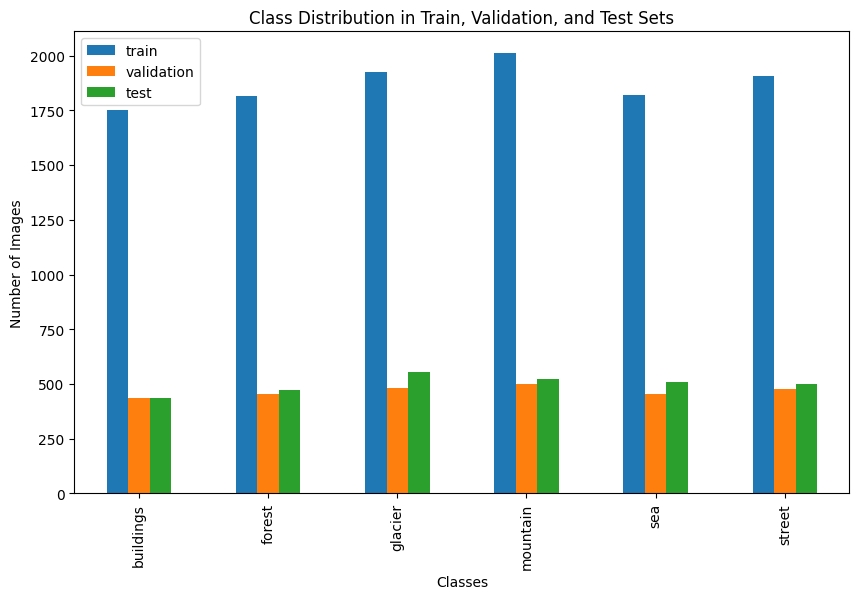

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Class names from generator
class_names = list(train_generator.class_indices.keys())

# Training and validation label counts
train_labels = train_generator.classes
val_labels = val_generator.classes
test_labels = test_generator.classes

# Count unique values
_, train_counts = np.unique(train_labels, return_counts=True)
_, val_counts = np.unique(val_labels, return_counts=True)
_, test_counts = np.unique(test_labels, return_counts=True)

# Combine into DataFrame
df_counts = pd.DataFrame({
    'train': train_counts,
    'validation': val_counts,
    'test': test_counts
}, index=class_names)

# Plot
df_counts.plot.bar(figsize=(10,6))
plt.title("Class Distribution in Train, Validation, and Test Sets")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

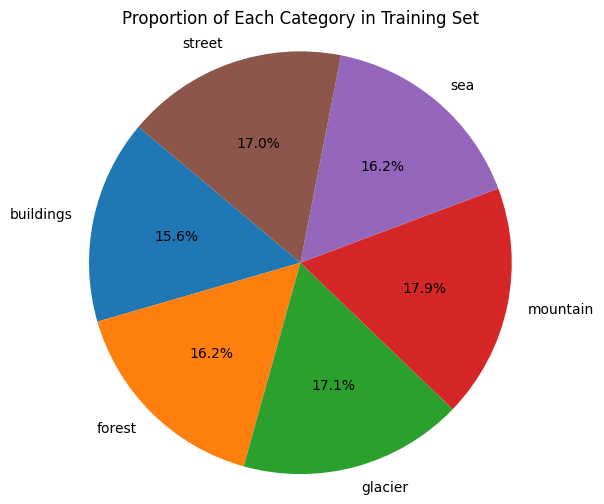

In [ ]:
# Pie chart for class proportions in training set
plt.figure(figsize=(6,6))
plt.pie(
    train_counts,
    labels=class_names,
    autopct='%1.1f%%',
    startangle=140
)
plt.axis('equal')  # Equal aspect ratio ensures circle
plt.title('Proportion of Each Category in Training Set')
plt.show()

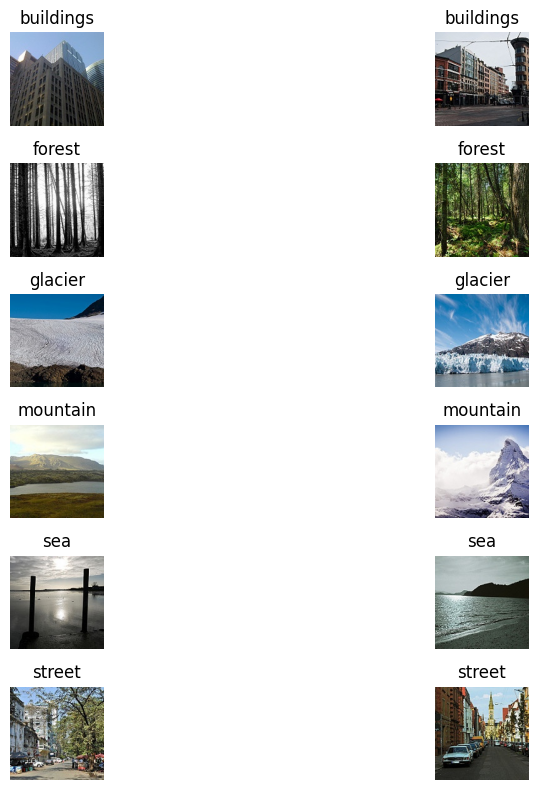

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_samples_per_class(generator, class_names, n=2):
    plt.figure(figsize=(12, 8))
    for idx, class_name in enumerate(class_names):
        # get file paths for class
        file_paths = generator.filepaths
        class_files = [f for f in file_paths if class_name in f]
        for j in range(n):
            plt.subplot(len(class_names), n, idx*n + j + 1)
            img = plt.imread(class_files[j])
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples_per_class(train_generator, class_names, n=2)

In [ ]:
sample_batch, _ = next(train_generator)
print("Batch shape:", sample_batch.shape)

Batch shape: (32, 150, 150, 3)


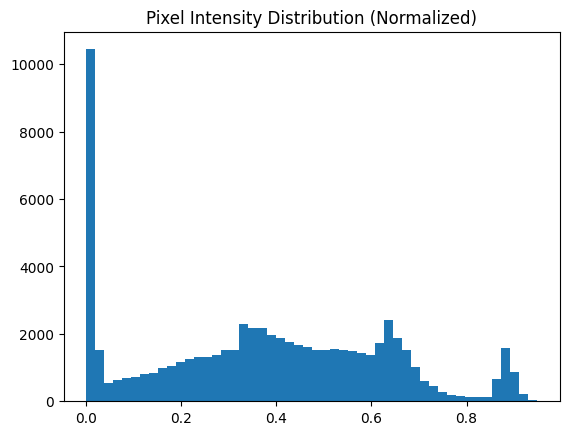

In [ ]:
plt.hist(sample_batch[0].ravel(), bins=50)
plt.title("Pixel Intensity Distribution (Normalized)")
plt.show()

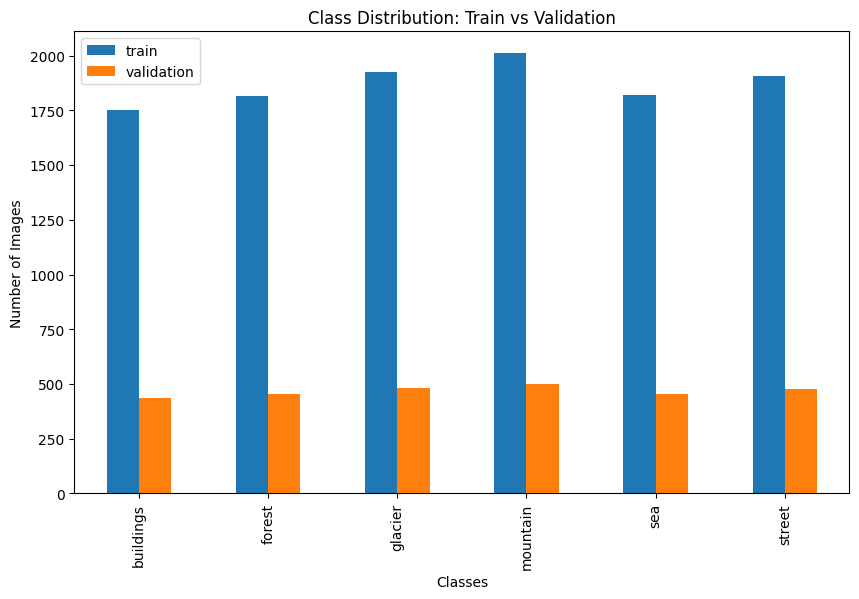

In [ ]:
# Compare train vs validation distribution
df_counts[['train', 'validation']].plot.bar(figsize=(10,6))
plt.title("Class Distribution: Train vs Validation")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
# Check image shapes directly from generator
batch_x, _ = next(train_generator)
print("Batch shape:", batch_x.shape)  # should be (32, 150, 150, 3)

# Verify across train set
all_shapes = [plt.imread(fp).shape for fp in train_generator.filepaths[:500]]  # check 500 images
unique_shapes = set(all_shapes)
print("Unique shapes found in dataset:", unique_shapes)

Batch shape: (32, 150, 150, 3)
Unique shapes found in dataset: {(150, 150, 3)}


In [ ]:
import hashlib

# Function to hash an image
def hash_image(filepath):
    with open(filepath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

# Compute hashes for first 2000 images
hashes = [hash_image(fp) for fp in train_generator.filepaths[:2000]]

# Check duplicates
duplicates = len(hashes) - len(set(hashes))
print(f"Found {duplicates} duplicate images in first 2000 samples")

Found 0 duplicate images in first 2000 samples


Base CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint


# --- Build Base CNN Model ---
base_cnn = Sequential([
    # 1st Convolutional block
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(pool_size=(2,2)),

    # 2nd Convolutional block
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # 3rd Convolutional block
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Flatten + Dense layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),   # prevent overfitting
    Dense(6, activation='softmax')  # 6 classes
])

# Compile model
base_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
base_cnn.summary()

# === Add Checkpoint Callback ===
checkpoint = ModelCheckpoint(
    filepath='base_cnn_best.h5',   # file to save weights
    monitor='val_accuracy',        # metric to monitor
    save_best_only=True,           # saves only best model
    mode='max',
    verbose=1
)

# --- Train Model ---
history = base_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,                     # start with 10
    callbacks=[checkpoint]         # add checkpoint
)




/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

...

351/351 ━━━━━━━━━━━━━━━━━━━━ 364s 1s/step - accuracy: 0.6574 - loss: 0.9279 - val_accuracy: 0.7097 - val_loss: 0.7987
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6864 - loss: 0.8485
Epoch 4: val_accuracy improved from 0.70970 to 0.73217, saving model to base_cnn_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 406s 1s/step - accuracy: 0.6864 - loss: 0.8485 - val_accuracy: 0.7322 - val_loss: 0.7293
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7144 - loss: 0.8026
Epoch 5: val_accuracy improved from 0.73217 to 0.75392, saving model to base_cnn_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 403s 1s/step - accuracy: 0.7144 - loss: 0.8026 - val_accuracy: 0.7539 - val_loss: 0.6842
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7220 - loss: 0.7642
Epoch 6: val_accuracy improved from 0.75392 to 0.77853, saving model to base_cnn_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 393s 1s/step - accuracy: 0.7220 - loss: 0.7641 - val_accuracy: 0.7785 - val_loss: 0.6347
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7449 - loss: 0.7002
Epoch 7: val_accuracy did not improve from 0.77853
351/351 ━━━━━━━━━━━━━━━━━━━━ 396s 1s/step - accuracy: 0.7449 - loss: 0.7002 - val_accuracy: 0.7660 - val_loss: 0.6524
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7585 - loss: 0.6836
Epoch 8: val_accuracy did not improve from 0.77853
351/351 ━━━━━━━━━━━━━━━━━━━━ 401s 1s/step - accuracy: 0.7585 - loss: 0.6836 - val_accuracy: 0.7767 - val_loss: 0.6307
Epoch 9/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7611 - loss: 0.6861
Epoch 9: val_accuracy improved from 0.77853 to 0.80171, saving model to base_cnn_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 397s 1s/step - accuracy: 0.7611 - loss: 0.6860 - val_accuracy: 0.8017 - val_loss: 0.5543
Epoch 10/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7730 - loss: 0.6394
Epoch 10: val_accuracy did not improve from 0.80171
351/351 ━━━━━━━━━━━━━━━━━━━━ 394s 1s/step - accuracy: 0.7730 - loss: 0.6394 - val_accuracy: 0.7914 - val_loss: 0.5783


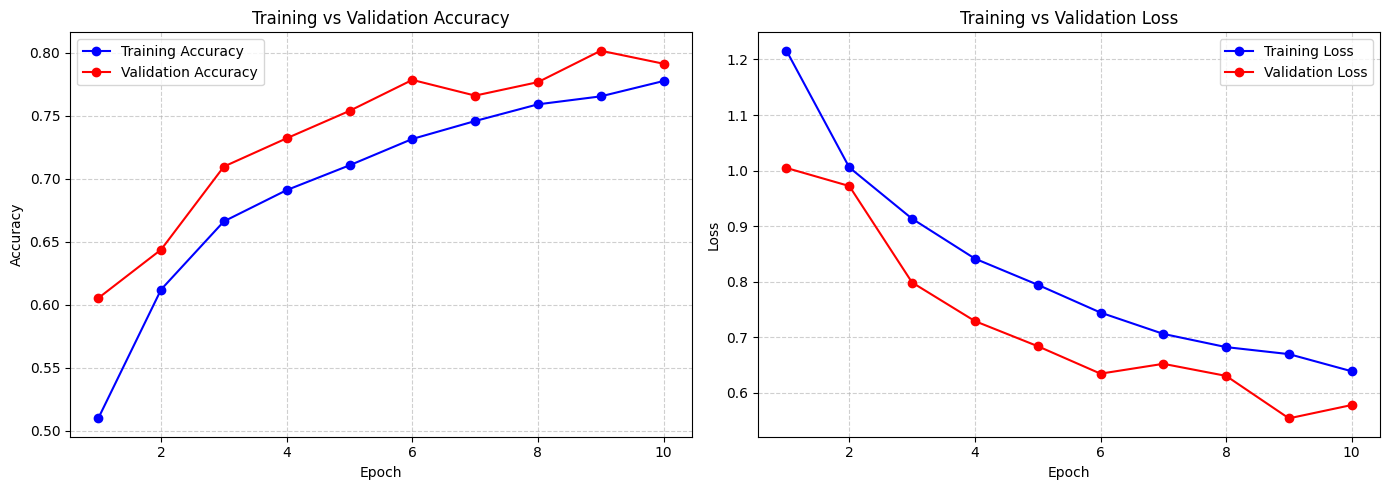

In [ ]:
# --- Extract metrics from history ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# --- Create subplots for evaluation ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(epochs, acc, 'bo-', label='Training Accuracy')
axes[0].plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# Loss plot
axes[1].plot(epochs, loss, 'bo-', label='Training Loss')
axes[1].plot(epochs, val_loss, 'ro-', label='Validation Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate on test set
test_loss, test_acc = base_cnn.evaluate(test_generator, verbose=1)

print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")


94/94 ━━━━━━━━━━━━━━━━━━━━ 36s 381ms/step - accuracy: 0.8256 - loss: 0.4827
✅ Test Accuracy: 0.8197
✅ Test Loss: 0.5088


In [ ]:
#%pip install keras_tuner
import keras_tuner as kt
import tensorflow as tf


def build_model(hp):
    model = Sequential([
        Conv2D(hp.Choice('conv1_filters', [32, 64]), (3,3), activation='relu', input_shape=(150,150,3)),
        MaxPooling2D(pool_size=(2,2)),

        Conv2D(hp.Choice('conv2_filters', [64, 128]), (3,3), activation='relu'),
        MaxPooling2D(pool_size=(2,2)),

        Conv2D(hp.Choice('conv3_filters', [128, 256]), (3,3), activation='relu'),
        MaxPooling2D(pool_size=(2,2)),

        Flatten(),
        Dense(hp.Choice('dense_units', [64, 128, 256, 512]), activation='relu'),
        Dropout(hp.Choice('dropout', [0.3, 0.4, 0.5, 0.6])),
        Dense(6, activation='softmax')
    ])

    # Learning rate as hyperparameter
    lr = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# RandomSearch Tuner with max_trials=10
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,        # Only 5 different hyperparameter combinations
    executions_per_trial=1,  # Run each trial once
    directory='kt_dir',
    project_name='cnn_tuning'
)

# Run search (5 epochs per trial)
tuner.search(train_generator, validation_data=val_generator, epochs=5)

# Get best model
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters:", best_hps.values)


Trial 5 Complete [01h 59m 33s]
val_accuracy: 0.6915121078491211

Best val_accuracy So Far: 0.7631954550743103
Total elapsed time: 08h 03m 08s
Best hyperparameters: {'conv1_filters': 64, 'conv2_filters': 64, 'conv3_filters': 256, 'dense_units': 128, 'dropout': 0.3, 'learning_rate': 0.001}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Eval for base CNN without Batch Normalization

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


94/94 ━━━━━━━━━━━━━━━━━━━━ 26s 278ms/step - accuracy: 0.8357 - loss: 0.4416
✅ Test Accuracy: 0.8123
✅ Test Loss: 0.5245
94/94 ━━━━━━━━━━━━━━━━━━━━ 26s 279ms/step


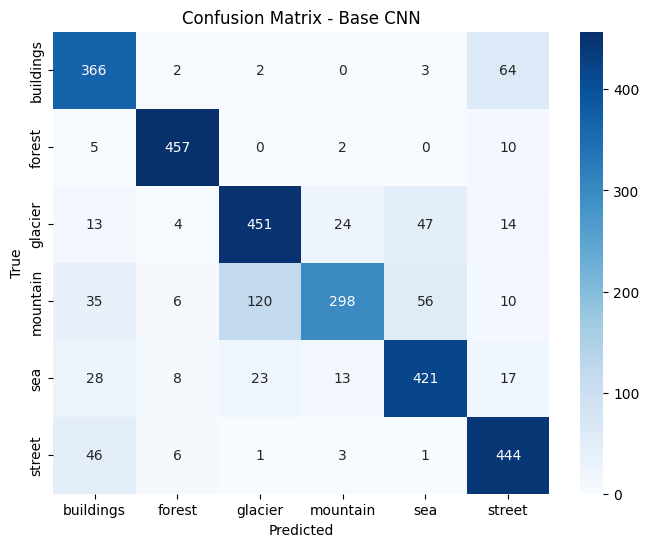


Classification Report:
              precision    recall  f1-score   support

   buildings       0.74      0.84      0.79       437
      forest       0.95      0.96      0.96       474
     glacier       0.76      0.82      0.78       553
    mountain       0.88      0.57      0.69       525
         sea       0.80      0.83      0.81       510
      street       0.79      0.89      0.84       501

    accuracy                           0.81      3000
   macro avg       0.82      0.82      0.81      3000
weighted avg       0.82      0.81      0.81      3000



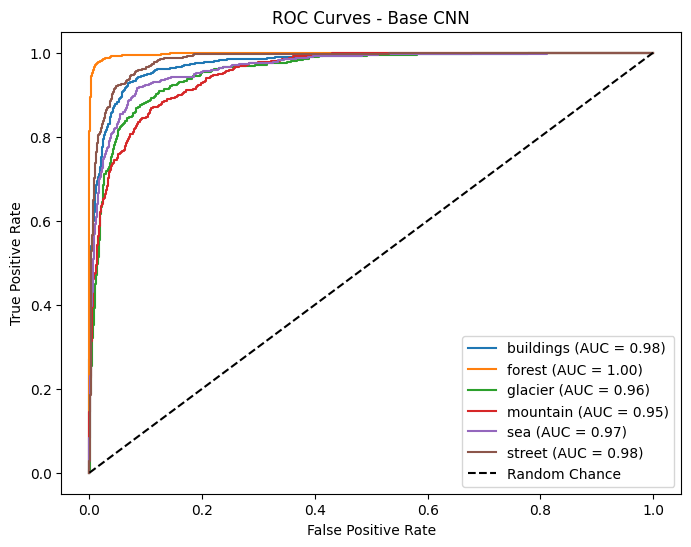

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# === Evaluate on Test Set ===
test_loss, test_acc = base_cnn.evaluate(test_generator, verbose=1)
print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")

# === Predictions ===
test_generator.reset()
y_pred = base_cnn.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# === Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Base CNN")
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# === ROC Curves ===
# One-hot encode true labels
y_true_bin = label_binarize(y_true, classes=np.arange(len(class_labels)))

plt.figure(figsize=(8,6))
for i in range(len(class_labels)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--', label="Random Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Base CNN")
plt.legend(loc="lower right")
plt.show()


Final Tuned CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns

# ----------------------------
# 1. Build your tuned CNN
# ----------------------------
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ----------------------------
# 2. Callbacks (Checkpoint + EarlyStopping)
# ----------------------------
checkpoint = ModelCheckpoint('best_model.h5',
                             monitor='val_accuracy',
                             save_best_only=True,
                             mode='max',
                             verbose=1)

earlystop = EarlyStopping(monitor='val_accuracy',
                          patience=5,
                          restore_best_weights=True,
                          verbose=1)

# ----------------------------
# 3. Train the model
# ----------------------------
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[checkpoint, earlystop]
)




Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4561 - loss: 1.3614
Epoch 1: val_accuracy improved from -inf to 0.61091, saving model to best_model.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 656s 2s/step - accuracy: 0.4563 - loss: 1.3609 - val_accuracy: 0.6109 - val_loss: 1.0116
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6123 - loss: 0.9924
Epoch 2: val_accuracy improved from 0.61091 to 0.68474, saving model to best_model.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 673s 2s/step - accuracy: 0.6124 - loss: 0.9923 - val_accuracy: 0.6847 - val_loss: 0.8486
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6717 - loss: 0.8665
Epoch 3: val_accuracy improved from 0.68474 to 0.70827, saving model to best_model.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 680s 2s/step - accuracy: 0.6718 - loss: 0.8664 - val_accuracy: 0.7083 - val_loss: 0.7553
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7097 - loss: 0.7785
Epoch 4: val_accuracy improved from 0.70827 to 0.76569, saving model to best_model.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 726s 2s/step - accuracy: 0.7098 - loss: 0.7785 - val_accuracy: 0.7657 - val_loss: 0.6573
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7499 - loss: 0.7080
Epoch 5: val_accuracy improved from 0.76569 to 0.77033, saving model to best_model.h5


...

351/351 ━━━━━━━━━━━━━━━━━━━━ 681s 2s/step - accuracy: 0.8048 - loss: 0.5391 - val_accuracy: 0.8195 - val_loss: 0.5133
Epoch 13/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8171 - loss: 0.5156
Epoch 13: val_accuracy did not improve from 0.81954
351/351 ━━━━━━━━━━━━━━━━━━━━ 660s 2s/step - accuracy: 0.8170 - loss: 0.5156 - val_accuracy: 0.8078 - val_loss: 0.5363
Epoch 14/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8108 - loss: 0.5314
Epoch 14: val_accuracy did not improve from 0.81954
351/351 ━━━━━━━━━━━━━━━━━━━━ 670s 2s/step - accuracy: 0.8108 - loss: 0.5314 - val_accuracy: 0.8131 - val_loss: 0.5230
Epoch 15/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8144 - loss: 0.5238
Epoch 15: val_accuracy improved from 0.81954 to 0.82489, saving model to best_model.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 659s 2s/step - accuracy: 0.8144 - loss: 0.5238 - val_accuracy: 0.8249 - val_loss: 0.5015
Epoch 16/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8245 - loss: 0.4884
Epoch 16: val_accuracy did not improve from 0.82489
351/351 ━━━━━━━━━━━━━━━━━━━━ 656s 2s/step - accuracy: 0.8245 - loss: 0.4885 - val_accuracy: 0.8124 - val_loss: 0.5210
Epoch 17/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8216 - loss: 0.5004
Epoch 17: val_accuracy improved from 0.82489 to 0.83203, saving model to best_model.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 650s 2s/step - accuracy: 0.8216 - loss: 0.5004 - val_accuracy: 0.8320 - val_loss: 0.4999
Epoch 18/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8246 - loss: 0.4889
Epoch 18: val_accuracy did not improve from 0.83203
351/351 ━━━━━━━━━━━━━━━━━━━━ 659s 2s/step - accuracy: 0.8246 - loss: 0.4889 - val_accuracy: 0.8267 - val_loss: 0.4954
Epoch 19/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8313 - loss: 0.4715
Epoch 19: val_accuracy improved from 0.83203 to 0.83310, saving model to best_model.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 659s 2s/step - accuracy: 0.8313 - loss: 0.4715 - val_accuracy: 0.8331 - val_loss: 0.4887
Epoch 20/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8320 - loss: 0.4716
Epoch 20: val_accuracy improved from 0.83310 to 0.83845, saving model to best_model.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 679s 2s/step - accuracy: 0.8320 - loss: 0.4716 - val_accuracy: 0.8384 - val_loss: 0.4555
Restoring model weights from the end of the best epoch: 20.


In [ ]:
history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,              # new total number of epochs
    initial_epoch=history.epoch[-1]+1,  # continue where you left off
    callbacks=[checkpoint, earlystop]
)

Epoch 21/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8331 - loss: 0.4527
Epoch 21: val_accuracy did not improve from 0.83845
351/351 ━━━━━━━━━━━━━━━━━━━━ 652s 2s/step - accuracy: 0.8331 - loss: 0.4527 - val_accuracy: 0.8167 - val_loss: 0.5203
Epoch 22/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8295 - loss: 0.4690
Epoch 22: val_accuracy improved from 0.83845 to 0.84344, saving model to best_model.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 650s 2s/step - accuracy: 0.8295 - loss: 0.4690 - val_accuracy: 0.8434 - val_loss: 0.4687
Epoch 23/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8347 - loss: 0.4593
Epoch 23: val_accuracy did not improve from 0.84344
351/351 ━━━━━━━━━━━━━━━━━━━━ 646s 2s/step - accuracy: 0.8347 - loss: 0.4593 - val_accuracy: 0.8267 - val_loss: 0.4993
Epoch 24/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8411 - loss: 0.4362
Epoch 24: val_accuracy did not improve from 0.84344
351/351 ━━━━━━━━━━━━━━━━━━━━ 648s 2s/step - accuracy: 0.8411 - loss: 0.4363 - val_accuracy: 0.8324 - val_loss: 0.5029
Epoch 25/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8434 - loss: 0.4372
Epoch 25: val_accuracy improved from 0.84344 to 0.84700, saving model to best_model.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 650s 2s/step - accuracy: 0.8434 - loss: 0.4372 - val_accuracy: 0.8470 - val_loss: 0.4324
Epoch 26/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8475 - loss: 0.4294
Epoch 26: val_accuracy improved from 0.84700 to 0.85770, saving model to best_model.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 651s 2s/step - accuracy: 0.8475 - loss: 0.4294 - val_accuracy: 0.8577 - val_loss: 0.4176
Epoch 27/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8466 - loss: 0.4310
Epoch 27: val_accuracy did not improve from 0.85770
351/351 ━━━━━━━━━━━━━━━━━━━━ 651s 2s/step - accuracy: 0.8466 - loss: 0.4310 - val_accuracy: 0.8417 - val_loss: 0.4570
Epoch 28/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8466 - loss: 0.4233
Epoch 28: val_accuracy did not improve from 0.85770
351/351 ━━━━━━━━━━━━━━━━━━━━ 647s 2s/step - accuracy: 0.8466 - loss: 0.4233 - val_accuracy: 0.8438 - val_loss: 0.4571
Epoch 29/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8457 - loss: 0.4345
Epoch 29: val_accuracy did not improve from 0.85770
351/351 ━━━━━━━━━━━━━━━━━━━━ 680s 2s/step - accuracy: 0.8457 - loss: 0.4345 - val_accuracy: 0.8367 - val_loss: 0.4625
Epoch 30/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8538 - loss: 0.4068
Epoch 30: val_accuracy did n

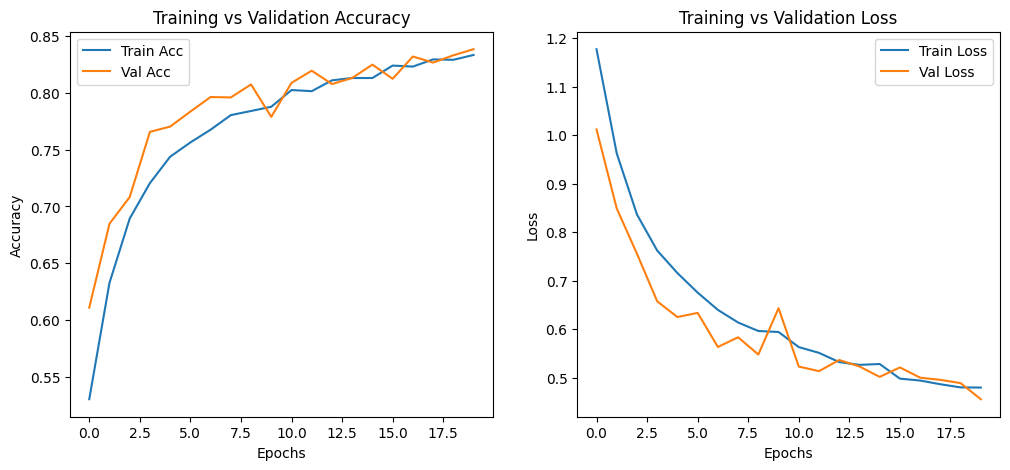

94/94 ━━━━━━━━━━━━━━━━━━━━ 45s 482ms/step - accuracy: 0.8743 - loss: 0.3511
Test Accuracy: 0.8630
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 470ms/step

Classification Report:
              precision    recall  f1-score   support

   buildings       0.83      0.87      0.85       437
      forest       0.98      0.97      0.97       474
     glacier       0.82      0.82      0.82       553
    mountain       0.82      0.77      0.80       525
         sea       0.88      0.86      0.87       510
      street       0.86      0.91      0.89       501

    accuracy                           0.86      3000
   macro avg       0.86      0.87      0.86      3000
weighted avg       0.86      0.86      0.86      3000



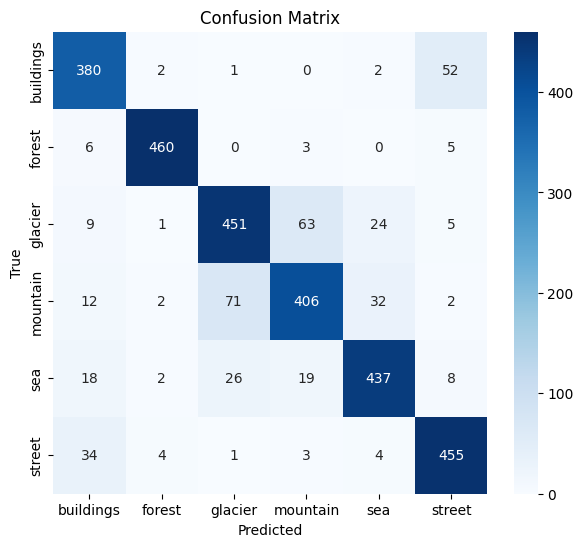

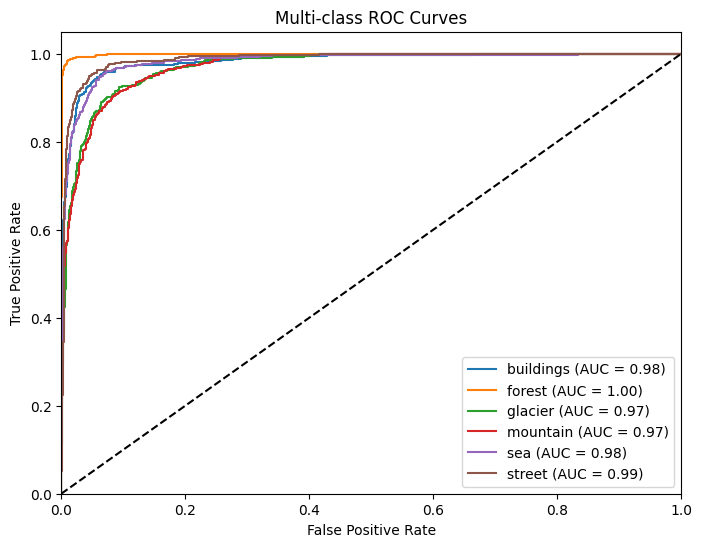

In [ ]:
# ----------------------------
# 4. Plot accuracy and loss
# ----------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# ----------------------------
# 5. Evaluate on test set
# ----------------------------
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

# ----------------------------
# 6. Classification report & Confusion Matrix
# ----------------------------
# Predict probabilities
test_generator.reset()
y_pred_proba = model.predict(test_generator)
# Predicted classes
y_pred = np.argmax(y_pred_proba, axis=1)
# True classes
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# ----------------------------
# 7. ROC Curves for each class
# ----------------------------
# Binarize true labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=range(len(class_labels)))

plt.figure(figsize=(8,6))
for i in range(len(class_labels)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')  # diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves')
plt.legend(loc='lower right')
plt.show()


RNN genearators

In [ ]:
# new generators using same augmentations but smaller target_size
train_generator_rnn = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),   # 👈 changed image size
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_generator_rnn = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

test_generator_rnn = test_datagen.flow_from_directory(
    test_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)


Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


Base RNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Reshape, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# === Build Improved (Stacked) RNN Model ===
timesteps = 64
features = 64 * 3  # flatten each row across width*channels

improved_rnn = Sequential([
    # reshape 64x64x3 to (64 timesteps, 64*3 features)
    Reshape((timesteps, features), input_shape=(64, 64, 3)),

    # 1st LSTM (returns sequences)
    LSTM(256, return_sequences=True),
    Dropout(0.3),

    # 2nd LSTM (outputs final sequence state)
    LSTM(128, return_sequences=False),
    Dropout(0.3),

    # Dense layers
    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(train_generator_rnn.num_classes, activation='softmax')
])

improved_rnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

improved_rnn.summary()

# === Callbacks ===
checkpoint = ModelCheckpoint(
    'improved_rnn_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# === Train Improved RNN ===
history_improved_rnn = improved_rnn.fit(
    train_generator_rnn,
    validation_data=val_generator_rnn,
    epochs=25,              # can try longer training
    callbacks=[checkpoint, earlystop]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_4 (Reshape)             │ (None, 64, 192)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64, 256)        │       459,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665,542 (2.54 MB)

 Trainable params: 665,542 (2.54 MB)

...

351/351 ━━━━━━━━━━━━━━━━━━━━ 185s 526ms/step - accuracy: 0.6197 - loss: 1.0181 - val_accuracy: 0.6191 - val_loss: 1.0093
Epoch 18/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.6284 - loss: 1.0045
Epoch 18: val_accuracy improved from 0.61912 to 0.62803, saving model to improved_rnn_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 183s 520ms/step - accuracy: 0.6284 - loss: 1.0045 - val_accuracy: 0.6280 - val_loss: 0.9937
Epoch 19/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.6359 - loss: 0.9908
Epoch 19: val_accuracy improved from 0.62803 to 0.64337, saving model to improved_rnn_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 185s 527ms/step - accuracy: 0.6359 - loss: 0.9908 - val_accuracy: 0.6434 - val_loss: 0.9445
Epoch 20/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.6425 - loss: 0.9751
Epoch 20: val_accuracy did not improve from 0.64337
351/351 ━━━━━━━━━━━━━━━━━━━━ 193s 550ms/step - accuracy: 0.6425 - loss: 0.9751 - val_accuracy: 0.6359 - val_loss: 0.9442
Epoch 21/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.6446 - loss: 0.9646
Epoch 21: val_accuracy did not improve from 0.64337
351/351 ━━━━━━━━━━━━━━━━━━━━ 183s 520ms/step - accuracy: 0.6446 - loss: 0.9646 - val_accuracy: 0.6345 - val_loss: 0.9640
Epoch 22/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.6474 - loss: 0.9616
Epoch 22: val_accuracy did not improve from 0.64337
351/351 ━━━━━━━━━━━━━━━━━━━━ 183s 522ms/step - accuracy: 0.6475 - loss: 0.9615 - val_accuracy: 0.6423 - val_loss: 0.9476
Epoch 23/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.6558 - loss: 0.9364
Epoc

351/351 ━━━━━━━━━━━━━━━━━━━━ 181s 516ms/step - accuracy: 0.6558 - loss: 0.9364 - val_accuracy: 0.6494 - val_loss: 0.9128
Epoch 24/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.6611 - loss: 0.9374
Epoch 24: val_accuracy improved from 0.64943 to 0.65799, saving model to improved_rnn_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 184s 524ms/step - accuracy: 0.6611 - loss: 0.9373 - val_accuracy: 0.6580 - val_loss: 0.9181
Epoch 25/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.6638 - loss: 0.9117
Epoch 25: val_accuracy did not improve from 0.65799
351/351 ━━━━━━━━━━━━━━━━━━━━ 188s 535ms/step - accuracy: 0.6638 - loss: 0.9117 - val_accuracy: 0.6573 - val_loss: 0.9226
Restoring model weights from the end of the best epoch: 24.


In [ ]:
test_loss, test_acc = improved_rnn.evaluate(test_generator_rnn)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - accuracy: 0.6384 - loss: 0.9607
Test Loss: 0.8613
Test Accuracy: 0.6920


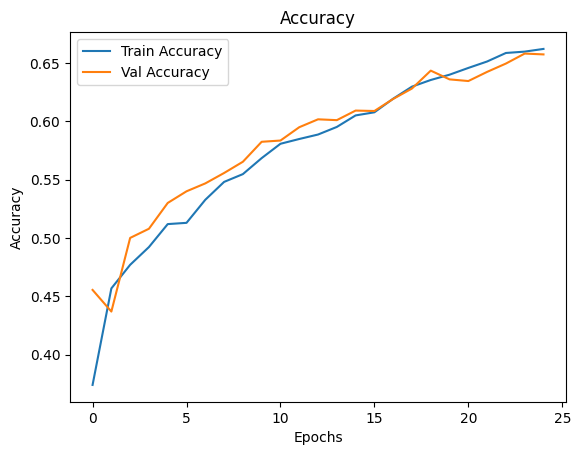

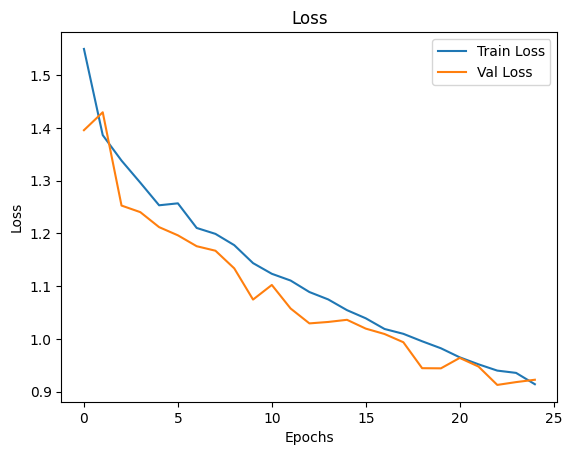

In [ ]:
import matplotlib.pyplot as plt

# Accuracy curve
plt.plot(history_improved_rnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_improved_rnn.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss curve
plt.plot(history_improved_rnn.history['loss'], label='Train Loss')
plt.plot(history_improved_rnn.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step


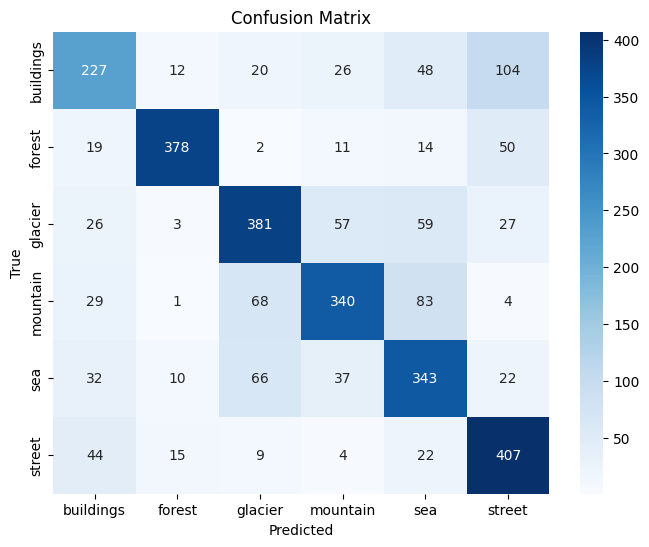

              precision    recall  f1-score   support

   buildings       0.60      0.52      0.56       437
      forest       0.90      0.80      0.85       474
     glacier       0.70      0.69      0.69       553
    mountain       0.72      0.65      0.68       525
         sea       0.60      0.67      0.64       510
      street       0.66      0.81      0.73       501

    accuracy                           0.69      3000
   macro avg       0.70      0.69      0.69      3000
weighted avg       0.70      0.69      0.69      3000



In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict on test set
y_pred_probs = improved_rnn.predict(test_generator_rnn)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator_rnn.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=list(test_generator_rnn.class_indices.keys()),
            yticklabels=list(test_generator_rnn.class_indices.keys()),
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print(classification_report(y_true, y_pred, target_names=list(test_generator_rnn.class_indices.keys())))


Bayesian

In [ ]:
#%pip install keras_tuner
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Reshape, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

timesteps = 64
features = 64 * 3  # flatten each row across width*channels

def build_rnn_model(hp):
    model = Sequential()
    model.add(Reshape((timesteps, features), input_shape=(64, 64, 3)))

    # --- Choose between LSTM or GRU ---
    rnn_layer_type = hp.Choice('rnn_type', ['LSTM', 'GRU'])

    # --- Number of recurrent layers ---
    num_rnn_layers = hp.Int('num_rnn_layers', 1, 3)

    for i in range(num_rnn_layers):
        units = hp.Int(f'rnn_units_{i}', 32, 256, step=32)
        return_seq = (i != num_rnn_layers - 1)
        if rnn_layer_type == 'LSTM':
            model.add(LSTM(units, return_sequences=return_seq))
        else:
            model.add(GRU(units, return_sequences=return_seq))
        model.add(Dropout(hp.Float(f'rnn_dropout_{i}', 0.1, 0.5, step=0.1)))

    # --- Dense layers ---
    num_dense_layers = hp.Int('num_dense_layers', 1, 3)
    for j in range(num_dense_layers):
        dense_units = hp.Int(f'dense_units_{j}', 32, 256, step=32)
        model.add(Dense(dense_units, activation='relu'))
        model.add(Dropout(hp.Float(f'dense_dropout_{j}', 0.1, 0.5, step=0.1)))

    # Output
    model.add(Dense(train_generator_rnn.num_classes, activation='softmax'))

    # Learning rate
    lr = hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# --- Bayesian Optimization Tuner ---
tuner = kt.BayesianOptimization(
    build_rnn_model,
    objective='val_accuracy',
    max_trials=5,            # how many configs to try in total
    executions_per_trial=1,   # how many times to repeat each trial
    directory='rnn_tuning_full',
    project_name='improved_rnn_bayesian'
)

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)

# --- Search ---
tuner.search(
    train_generator_rnn,
    validation_data=val_generator_rnn,
    epochs=10,  # number of epochs for each trial
    callbacks=[stop_early]
)

# --- Best hyperparameters ---
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters:")
print(f"RNN Type: {best_hps.get('rnn_type')}")
print(f"Number of RNN layers: {best_hps.get('num_rnn_layers')}")
print(f"Units per RNN layer: {[best_hps.get(f'rnn_units_{i}') for i in range(best_hps.get('num_rnn_layers'))]}")
print(f"Dropout per RNN layer: {[best_hps.get(f'rnn_dropout_{i}') for i in range(best_hps.get('num_rnn_layers'))]}")
print(f"Number of Dense layers: {best_hps.get('num_dense_layers')}")
print(f"Units per Dense layer: {[best_hps.get(f'dense_units_{j}') for j in range(best_hps.get('num_dense_layers'))]}")
print(f"Dropout per Dense layer: {[best_hps.get(f'dense_dropout_{j}') for j in range(best_hps.get('num_dense_layers'))]}")
print(f"Learning rate: {best_hps.get('learning_rate')}")


Trial 5 Complete [00h 13m 57s]
val_accuracy: 0.5413694977760315

Best val_accuracy So Far: 0.6166191101074219
Total elapsed time: 01h 01m 52s
Best hyperparameters:
RNN Type: GRU
Number of RNN layers: 1
Units per RNN layer: [128]
Dropout per RNN layer: [0.4]
Number of Dense layers: 1
Units per Dense layer: [160]
Dropout per Dense layer: [0.1]
Learning rate: 0.001


final tuned rnn

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Reshape, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

timesteps = 64
features = 64 * 3  # flatten each row across width*channels

# --- Tuned & extended hyperparameters ---
rnn_type = 'GRU'
num_rnn_layers = 2
rnn_units = [128, 64]       # 1st GRU 128, 2nd GRU 64
rnn_dropout = [0.4, 0.3]    # Dropout for each layer

dense_units = [160]         # From tuner
dense_dropout = [0.1]
learning_rate = 0.001

# --- Build model ---
tuned_rnn = Sequential()
tuned_rnn.add(Reshape((timesteps, features), input_shape=(64, 64, 3)))

# Add GRU layers
for i in range(num_rnn_layers):
    return_seq = (i < num_rnn_layers - 1)
    tuned_rnn.add(GRU(rnn_units[i], return_sequences=return_seq))
    tuned_rnn.add(Dropout(rnn_dropout[i]))

# Dense layers
for j in range(len(dense_units)):
    tuned_rnn.add(Dense(dense_units[j], activation='relu'))
    tuned_rnn.add(Dropout(dense_dropout[j]))

# Output layer
tuned_rnn.add(Dense(train_generator_rnn.num_classes, activation='softmax'))

# Compile
tuned_rnn.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tuned_rnn.summary()

# === Callbacks ===
checkpoint = ModelCheckpoint(
    'tuned_rnn_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train (with your existing callbacks)
history_tuned_rnn = tuned_rnn.fit(
    train_generator_rnn,
    validation_data=val_generator_rnn,
    epochs=25,
    callbacks=[checkpoint, earlystop]
)



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_3 (Reshape)             │ (None, 64, 192)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 64, 128)        │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 160)            │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           966 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,262 (672.90 KB)

 Trainable params: 172,262 (672.90 KB)

 Non-trainable params: 0 (0.00 B)

...

351/351 ━━━━━━━━━━━━━━━━━━━━ 72s 204ms/step - accuracy: 0.6527 - loss: 0.9431 - val_accuracy: 0.6566 - val_loss: 0.9166
Epoch 15/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.6667 - loss: 0.9141
Epoch 15: val_accuracy did not improve from 0.65656
351/351 ━━━━━━━━━━━━━━━━━━━━ 72s 204ms/step - accuracy: 0.6667 - loss: 0.9141 - val_accuracy: 0.6398 - val_loss: 0.9669
Epoch 16/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.6643 - loss: 0.9246
Epoch 16: val_accuracy improved from 0.65656 to 0.66191, saving model to tuned_rnn_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 201ms/step - accuracy: 0.6643 - loss: 0.9246 - val_accuracy: 0.6619 - val_loss: 0.9157
Epoch 17/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.6633 - loss: 0.9070
Epoch 17: val_accuracy improved from 0.66191 to 0.67939, saving model to tuned_rnn_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 74s 210ms/step - accuracy: 0.6633 - loss: 0.9069 - val_accuracy: 0.6794 - val_loss: 0.8644
Epoch 18/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.6671 - loss: 0.8823
Epoch 18: val_accuracy did not improve from 0.67939
351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 202ms/step - accuracy: 0.6671 - loss: 0.8823 - val_accuracy: 0.6655 - val_loss: 0.8933
Epoch 19/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.6789 - loss: 0.8725
Epoch 19: val_accuracy did not improve from 0.67939
351/351 ━━━━━━━━━━━━━━━━━━━━ 72s 206ms/step - accuracy: 0.6789 - loss: 0.8725 - val_accuracy: 0.6534 - val_loss: 0.9278
Epoch 20/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.6802 - loss: 0.8660
Epoch 20: val_accuracy did not improve from 0.67939
351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 202ms/step - accuracy: 0.6802 - loss: 0.8660 - val_accuracy: 0.6712 - val_loss: 0.8712
Epoch 21/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.6828 - loss: 0.8584
Epoch 21

351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 202ms/step - accuracy: 0.6793 - loss: 0.8451 - val_accuracy: 0.6869 - val_loss: 0.8395
Epoch 23/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.6988 - loss: 0.8293
Epoch 23: val_accuracy improved from 0.68688 to 0.69900, saving model to tuned_rnn_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 207ms/step - accuracy: 0.6988 - loss: 0.8293 - val_accuracy: 0.6990 - val_loss: 0.8253
Epoch 24/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.6941 - loss: 0.8252
Epoch 24: val_accuracy did not improve from 0.69900
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 207ms/step - accuracy: 0.6941 - loss: 0.8252 - val_accuracy: 0.6933 - val_loss: 0.8369
Epoch 25/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.7003 - loss: 0.8134
Epoch 25: val_accuracy did not improve from 0.69900
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 207ms/step - accuracy: 0.7003 - loss: 0.8134 - val_accuracy: 0.6733 - val_loss: 0.8873
Restoring model weights from the end of the best epoch: 23.


In [ ]:
# load the best weights first if needed
tuned_rnn.load_weights('tuned_rnn_best.h5')

# continue training for 10 more epochs
history_tuned_rnn2 = tuned_rnn.fit(
    train_generator_rnn,
    validation_data=val_generator_rnn,
    initial_epoch=25,  # start counting from previous epochs
    epochs=45,         # total epoch count (25 + 20)
    callbacks=[checkpoint, earlystop]
)


Epoch 26/45
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.6934 - loss: 0.8348
Epoch 26: val_accuracy did not improve from 0.69900
351/351 ━━━━━━━━━━━━━━━━━━━━ 75s 214ms/step - accuracy: 0.6934 - loss: 0.8348 - val_accuracy: 0.6879 - val_loss: 0.8297
Epoch 27/45
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.6962 - loss: 0.8350
Epoch 27: val_accuracy did not improve from 0.69900
351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 202ms/step - accuracy: 0.6962 - loss: 0.8349 - val_accuracy: 0.6705 - val_loss: 0.8837
Epoch 28/45
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.6942 - loss: 0.8172
Epoch 28: val_accuracy did not improve from 0.69900
351/351 ━━━━━━━━━━━━━━━━━━━━ 72s 205ms/step - accuracy: 0.6942 - loss: 0.8172 - val_accuracy: 0.6937 - val_loss: 0.8286
Epoch 29/45
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.7020 - loss: 0.8009
Epoch 29: val_accuracy improved from 0.69900 to 0.70292, saving model to tuned_rnn_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 201ms/step - accuracy: 0.7020 - loss: 0.8009 - val_accuracy: 0.7029 - val_loss: 0.8132
Epoch 30/45
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.6973 - loss: 0.8113
Epoch 30: val_accuracy did not improve from 0.70292
351/351 ━━━━━━━━━━━━━━━━━━━━ 74s 209ms/step - accuracy: 0.6973 - loss: 0.8113 - val_accuracy: 0.6894 - val_loss: 0.8174
Epoch 31/45
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.7086 - loss: 0.7996
Epoch 31: val_accuracy did not improve from 0.70292
351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 203ms/step - accuracy: 0.7086 - loss: 0.7995 - val_accuracy: 0.7019 - val_loss: 0.8119
Epoch 32/45
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.7041 - loss: 0.7906
Epoch 32: val_accuracy improved from 0.70292 to 0.71077, saving model to tuned_rnn_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 207ms/step - accuracy: 0.7041 - loss: 0.7906 - val_accuracy: 0.7108 - val_loss: 0.7980
Epoch 33/45
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.7106 - loss: 0.7790
Epoch 33: val_accuracy did not improve from 0.71077
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 207ms/step - accuracy: 0.7106 - loss: 0.7790 - val_accuracy: 0.6997 - val_loss: 0.8349
Epoch 34/45
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.6975 - loss: 0.8006
Epoch 34: val_accuracy did not improve from 0.71077
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 205ms/step - accuracy: 0.6975 - loss: 0.8006 - val_accuracy: 0.7004 - val_loss: 0.8293
Epoch 35/45
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.7240 - loss: 0.7658
Epoch 35: val_accuracy did not improve from 0.71077
351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 203ms/step - accuracy: 0.7240 - loss: 0.7658 - val_accuracy: 0.7044 - val_loss: 0.7970
Epoch 36/45
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.7128 - loss: 0.7732
Epoch 36

351/351 ━━━━━━━━━━━━━━━━━━━━ 72s 206ms/step - accuracy: 0.7146 - loss: 0.7747 - val_accuracy: 0.7215 - val_loss: 0.7755
Epoch 38/45
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.7192 - loss: 0.7722
Epoch 38: val_accuracy did not improve from 0.72147
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 205ms/step - accuracy: 0.7192 - loss: 0.7722 - val_accuracy: 0.6997 - val_loss: 0.8057
Epoch 39/45
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.7245 - loss: 0.7633
Epoch 39: val_accuracy did not improve from 0.72147
351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 202ms/step - accuracy: 0.7245 - loss: 0.7633 - val_accuracy: 0.7136 - val_loss: 0.7694
Epoch 40/45
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.7209 - loss: 0.7562
Epoch 40: val_accuracy did not improve from 0.72147
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 209ms/step - accuracy: 0.7209 - loss: 0.7562 - val_accuracy: 0.7058 - val_loss: 0.8000
Epoch 41/45
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.7292 - loss: 0.7398
Epoch 41

In [ ]:
# After your second training finishes:
# Evaluate on validation data
val_loss, val_acc = tuned_rnn.evaluate(val_generator_rnn)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

# If you have a separate test generator/dataset:
test_loss, test_acc = tuned_rnn.evaluate(test_generator_rnn)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - accuracy: 0.7227 - loss: 0.7674
Validation Loss: 0.7719
Validation Accuracy: 0.7240
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.6851 - loss: 0.7840
Test Loss: 0.7280
Test Accuracy: 0.7297


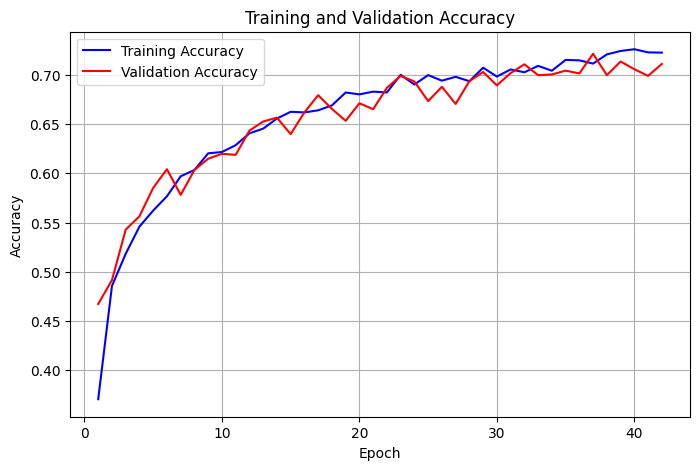

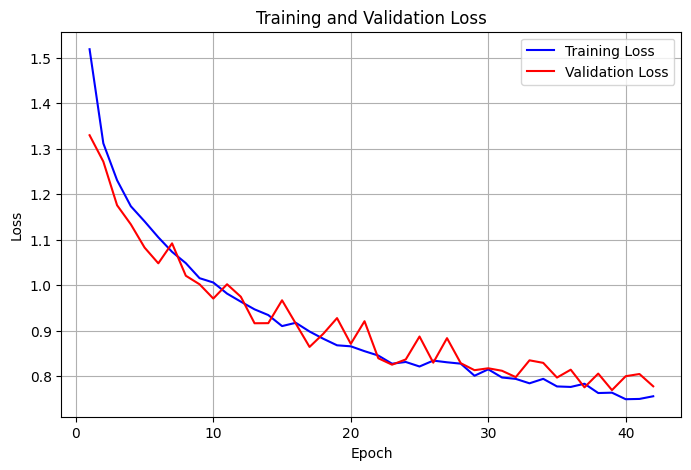

In [ ]:
import matplotlib.pyplot as plt

# Combine both history dictionaries
acc = history_tuned_rnn.history['accuracy'] + history_tuned_rnn2.history['accuracy']
val_acc = history_tuned_rnn.history['val_accuracy'] + history_tuned_rnn2.history['val_accuracy']

loss = history_tuned_rnn.history['loss'] + history_tuned_rnn2.history['loss']
val_loss = history_tuned_rnn.history['val_loss'] + history_tuned_rnn2.history['val_loss']

epochs = range(1, len(acc) + 1)

# --- Plot Accuracy ---
plt.figure(figsize=(8,5))
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot Loss ---
plt.figure(figsize=(8,5))
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step
              precision    recall  f1-score   support

   buildings       0.65      0.56      0.60       437
      forest       0.82      0.88      0.84       474
     glacier       0.74      0.70      0.72       553
    mountain       0.71      0.75      0.73       525
         sea       0.72      0.68      0.70       510
      street       0.73      0.80      0.76       501

    accuracy                           0.73      3000
   macro avg       0.73      0.73      0.73      3000
weighted avg       0.73      0.73      0.73      3000



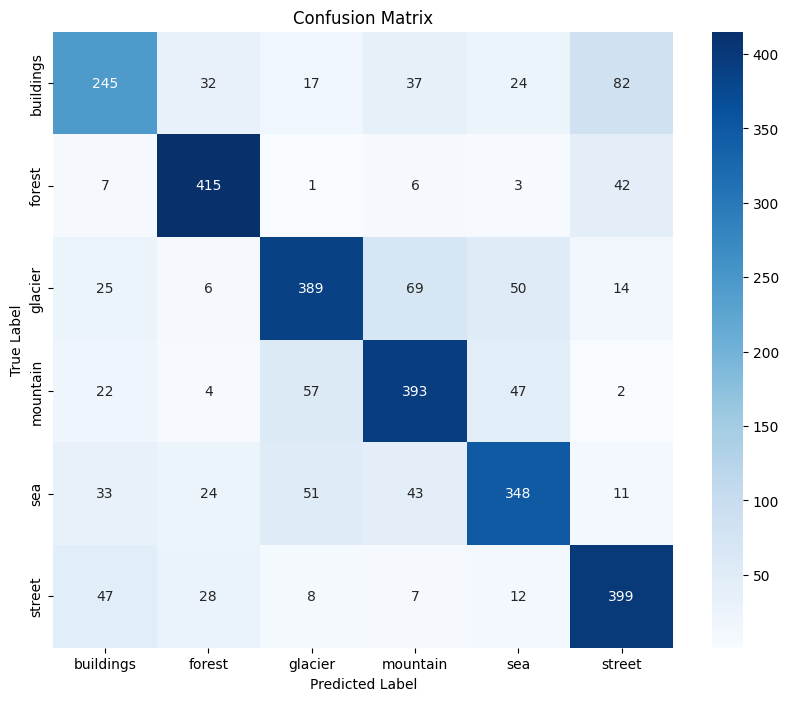

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Get predictions on the test set ---
# if your generator is test_generator_rnn (replace with yours)
y_pred_probs = tuned_rnn.predict(test_generator_rnn)   # shape: (num_samples, num_classes)
y_pred = np.argmax(y_pred_probs, axis=1)               # predicted class indices

# True labels from generator
y_true = test_generator_rnn.classes                    # ground truth indices
class_labels = list(test_generator_rnn.class_indices.keys())  # class names

# --- 2. Classification Report ---
print(classification_report(y_true, y_pred, target_names=class_labels))

# --- 3. Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)

# --- 4. Plot Confusion Matrix ---
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()
